In [1]:
import os
import matplotlib.pyplot as plt
import cv2
import random
import pandas as pd
import numpy as np

In [2]:
from nazi_symbols_classification.training.data_preparation import get_image_paths

In [3]:
image_files = get_image_paths("/home/zhiwei/Projects/nazi-symbols-classification/datasets/nazi-symbols-classification-original", 
                              ("train", ))
print(f"Total Images: {len(image_files)}")

Total Images: 3509


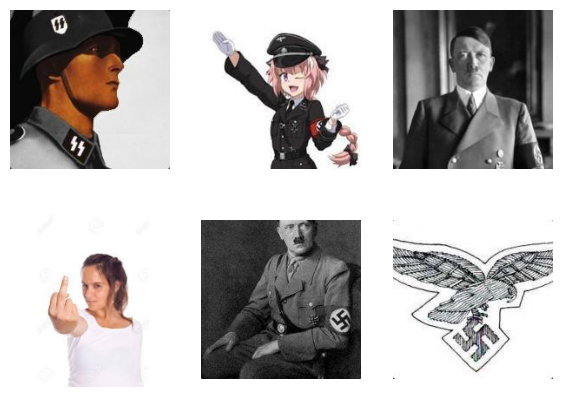

In [4]:
# Display sample images
sample_images = random.sample(image_files, 6)
fig, axes = plt.subplots(2, 3, figsize=(7, 5))
for i, ax_l in enumerate(axes):
    for j, ax in enumerate(ax_l):
        img_file = sample_images[i * 3 + j]
        img = cv2.imread(img_file)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.axis("off")
plt.savefig('nazi-symbols-classification-examples.png')
plt.show()

In [5]:
labels = [os.path.basename(os.path.dirname(image_file)) for image_file in image_files]

In [6]:
df = pd.DataFrame({"path": image_files, "label": labels})
df.head()

,path,label
0,/home/zhiwei/Projects/nazi-symbols-classificat...,hitler_salute
1,/home/zhiwei/Projects/nazi-symbols-classificat...,hitler_salute
2,/home/zhiwei/Projects/nazi-symbols-classificat...,hitler_salute
3,/home/zhiwei/Projects/nazi-symbols-classificat...,hitler_salute
4,/home/zhiwei/Projects/nazi-symbols-classificat...,hitler_salute


In [7]:
replacement_dict = dict(
    hitler_salute="Nazi salute", 
    british_union_of_fascist="Flash and circle", 
    doppelsiegrune="Doppelsiegrune",
    sturmabteilung_emblem="Sturmabteilung emblem",
    combat_18_emblem="Combat 18 emblem", 
    ss_skull="SS Skull",
    black_sun="Sonnenrad",
    hitler="Hitler", 
    judenstern="Yellow badge",
    golden_dawn="Golden Dawn",
    wolfsangel="Wolfsangel",
    celtic_cross="Celtic Cross",
    broken_sun_cross="Broken Sun Cross",
    hammerskins="Hammerskins emblem",
    national_rebirth_poland="National Rebirth of Poland emblem", 
    happy_merchant="The Happy Merchant", 
    kolovrat="Kolovrat",
    volksfront_emblem="Popular front emblem", 
    identitaere_bewegung_emblem="Identitarian movement emblem", 
    swastika="Swastika",
    atomwaffen="Atomwaffen Division emblem", 
    siegrune="Siegrune", 
    blood_honor_emblem="Blood & Honor emblem"
)

df["label"] = df.label.replace(replacement_dict)
# df.label.unique()

In [8]:
def wrap_title(string, max_length):
    result = []
    string = string.split()
    temp = ""
    for word in string:
        if len(temp + word) > max_length:
            result.append(temp)
            temp = ""
        elif len(temp) > 0:
            temp += " "
        temp += word
    result.append(temp)
    return "\n".join(result)

wrap_title("Combat 18 emblem", 15)

'Combat 18 emblem'

In [19]:
df.label.unique().tolist(), len(df.label.unique())

(['Nazi salute',
  'Flash and circle',
  'Doppelsiegrune',
  'Sturmabteilung emblem',
  'Combat 18 emblem',
  'SS Skull',
  'Sonnenrad',
  'non-nazi',
  'Hitler',
  'Yellow badge',
  'Golden Dawn',
  'Wolfsangel',
  'Celtic Cross',
  'Broken Sun Cross',
  'Hammerskins emblem',
  'National Rebirth of Poland emblem',
  'The Happy Merchant',
  'Kolovrat',
  'Popular front emblem',
  'Identitarian movement emblem',
  'Swastika',
  'Atomwaffen Division emblem',
  'Siegrune',
  'Blood & Honor emblem'],
 24)

In [70]:
df.path[0]

'/home/zhiwei/Projects/nazi-symbols-classification/datasets/nazi-symbols-classification-original/train/hitler_salute/846a76fdfef4792fbb41d44433ae43e4ce5b5ffb_full_jpg.rf.1f022c687f9632b0d1d3d01a8fd8c851.jpg'

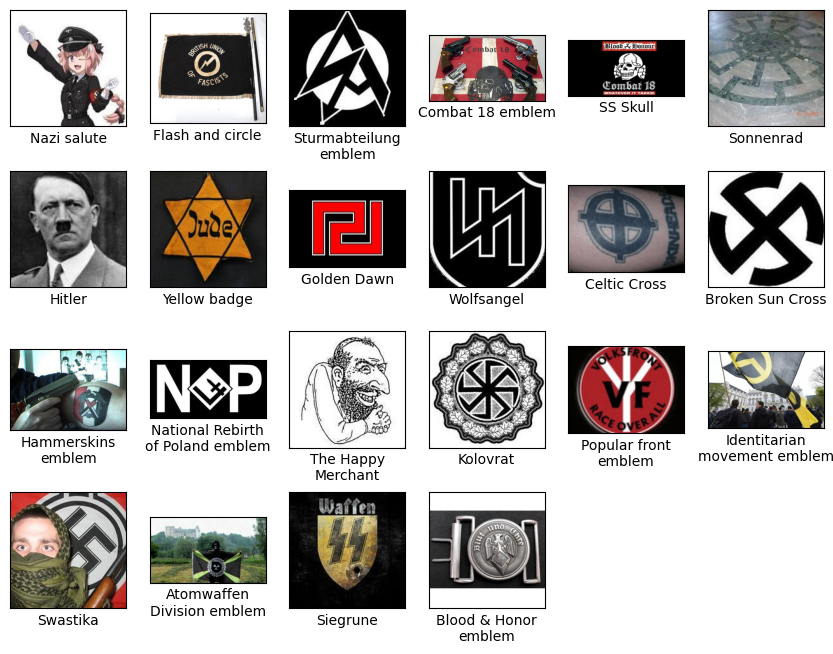

In [78]:
fig, axes = plt.subplots(4, 6, figsize=(10.5, 8))
unique_labels = df.label.unique().tolist()
unique_labels.remove('non-nazi')
unique_labels.remove('Doppelsiegrune')
displayed_image_names = []

for i, ax_l in enumerate(axes):
    for j, ax in enumerate(ax_l):
        if i * 6 + j >= len(unique_labels): 
            ax.axis("off")
            continue
        img_cls = unique_labels[i * 6 + j]
        if img_cls == "The Happy Merchant":
            img_file = "/home/zhiwei/Projects/nazi-symbols-classification/datasets/nazi-symbols-classification-original/train/happy_merchant/9bc2c7e52b007d50471a35afd01e9580ebbb4fc9_full_jpg.rf.4c8d8e359dfa1c07bc863b8c2bdebc2f.jpg"
            image_file_name = os.path.basename(img_file)
        else:
            img_file = random.sample(df[df.label == img_cls].path.tolist(), 1)[0]
            image_file_name = os.path.basename(img_file)
            while image_file_name in displayed_image_names:
                img_file = random.sample(df[df.label == img_cls].path.tolist(), 1)[0]
                image_file_name = os.path.basename(img_file)
        displayed_image_names.append(image_file_name)
        img = cv2.imread(img_file)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        # ax.axis("off")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel(wrap_title(img_cls, 15))
plt.savefig('nazi-symbol-examples.png')
plt.show()

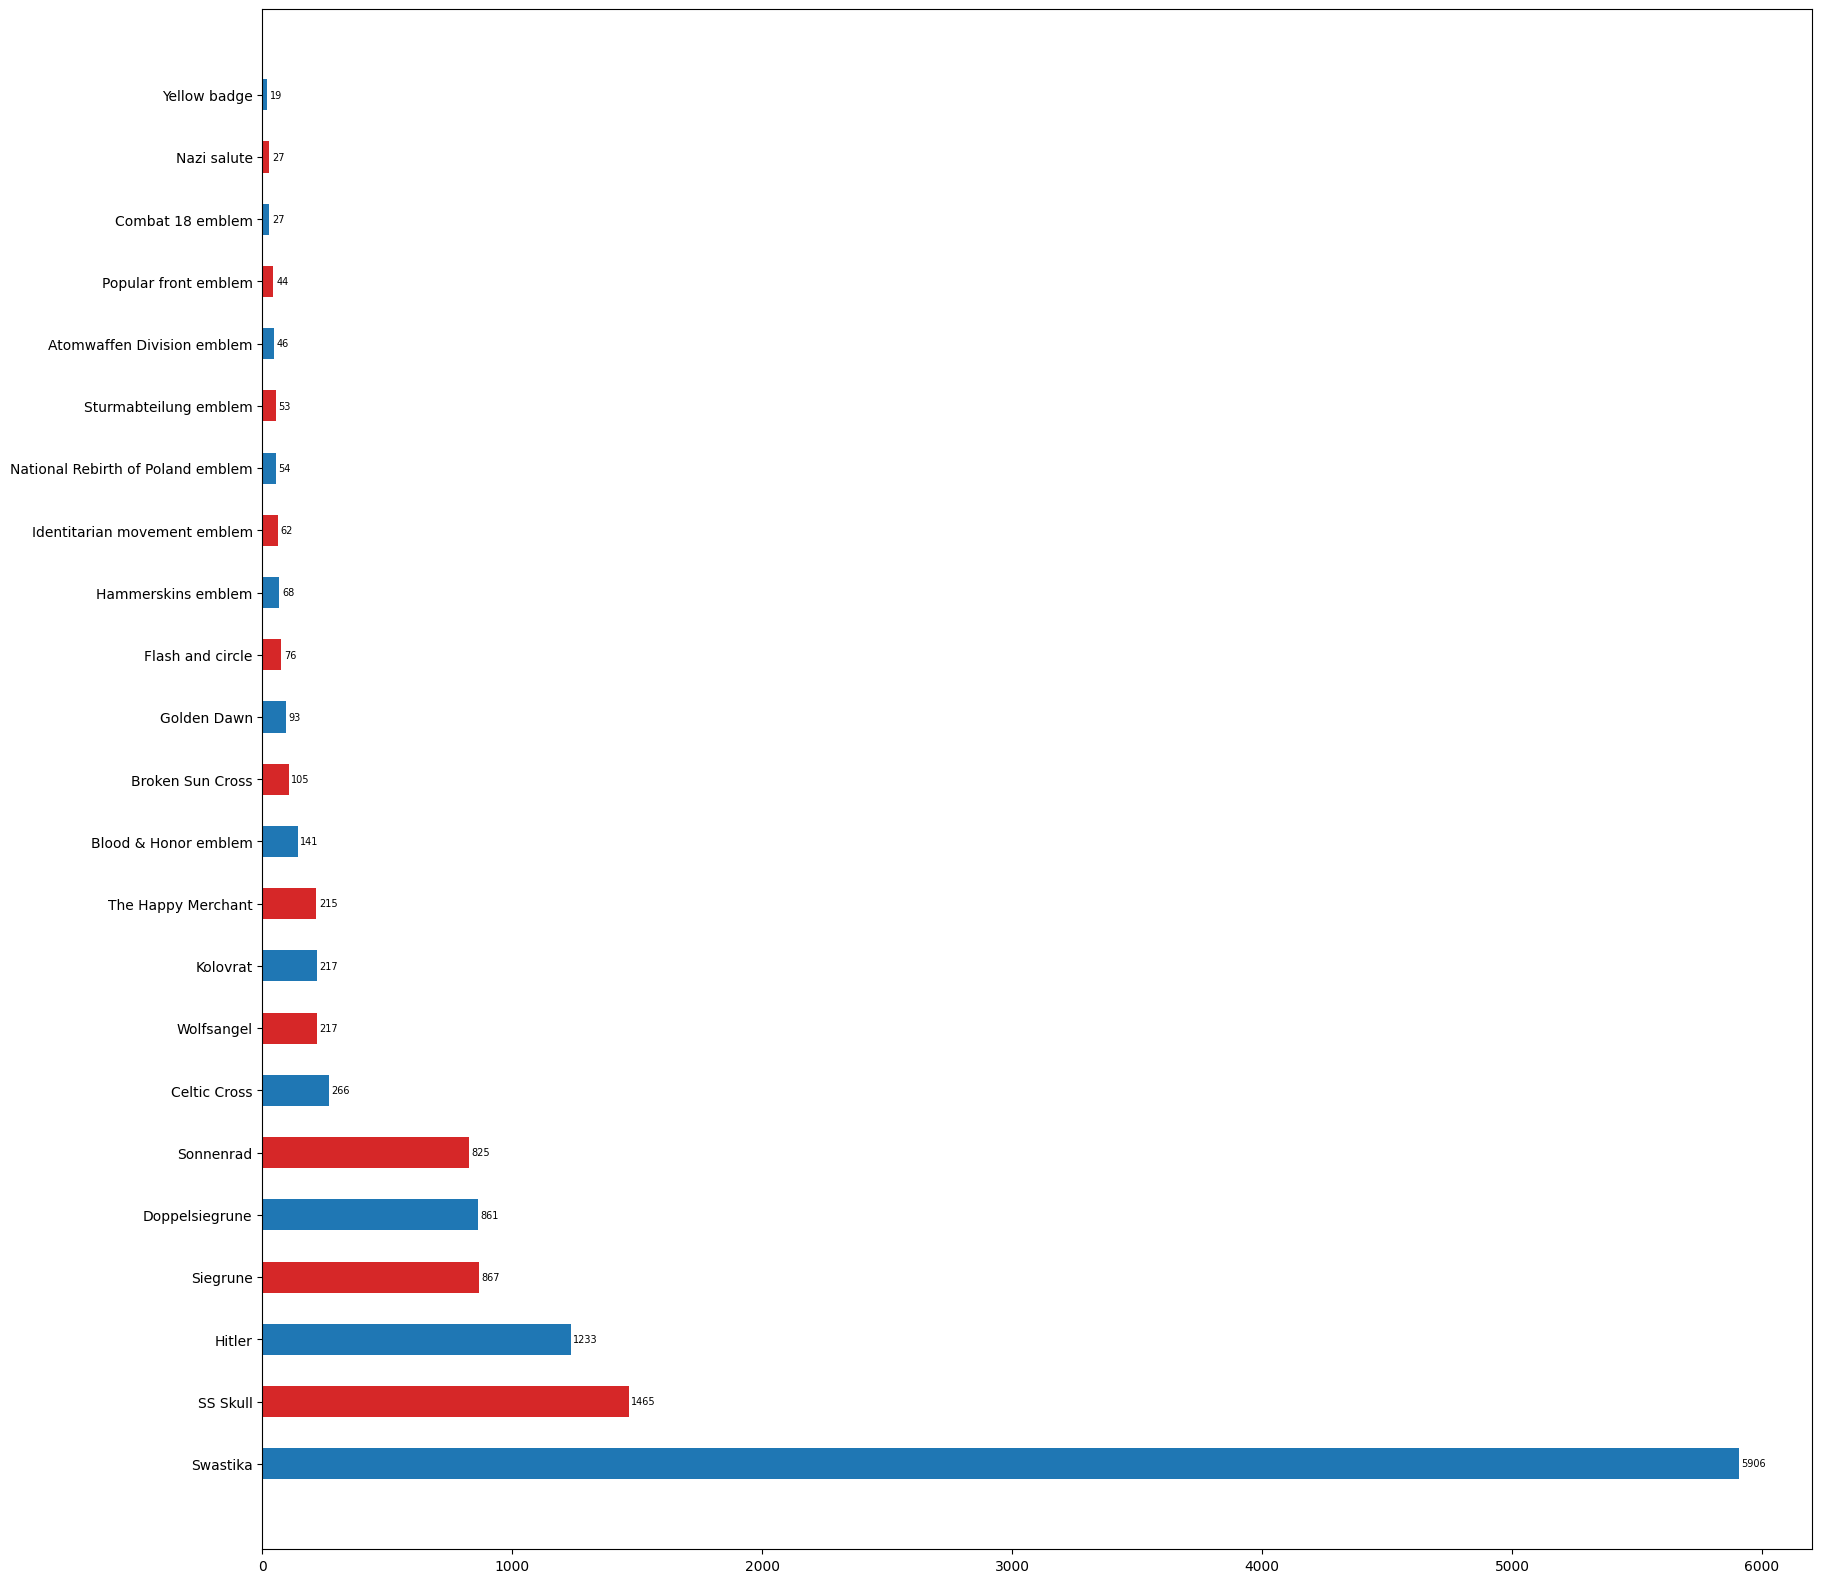

In [74]:
plt.figure(figsize=(20,20))

value_counts = df["label"].value_counts().to_dict()

img_cls, img_number = tuple(zip(*value_counts.items()))
width = 0.5
x = np.arange(len(value_counts))  # the label locations

bar_colors = ['tab:blue', 'tab:red']

rects = plt.barh(img_cls, img_number, width, color=bar_colors)
plt.bar_label(rects, padding=2, fontsize=7)

plt.ylabel='Number of images'
plt.title='Image Class Distribution'
plt.ylim = (0,7000)
# plt.xticks(ticks=x, labels=img_cls, rotation=45 ) ;

plt.savefig('nazi-classification-distribution.png')
plt.show()

In [69]:
# Compute mean and std deviation across dataset
means, stds = [], []
for img_file in image_files:
    img = cv2.imread(img_file)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) / 255.0
    means.append(np.mean(img, axis=(0, 1)))
    stds.append(np.std(img, axis=(0, 1)))

means = np.mean(means, axis=0)
stds = np.mean(stds, axis=0)
print(f"Mean: {means}, Std Dev: {stds}")

Mean: [0.44405632 0.44166248 0.4416103 ], Std Dev: [0.28905524 0.28752552 0.28753392]


In [70]:
def detect_blur(img_path, threshold=100):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    laplacian_var = cv2.Laplacian(img, cv2.CV_64F).var()
    return laplacian_var < threshold

blurred_images = [f for f in image_files if detect_blur(f)]

In [71]:
print(f"Blurred Images: {len(blurred_images)}")

Blurred Images: 6883


In [43]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=3, min_samples=2).fit(features.cpu().detach().numpy())
print(f"Number of outliers: {sum(dbscan.labels_ == -1)}")

Number of outliers: 1
